In [118]:
from sklearn.ensemble import RandomForestClassifier
import pandas as pd
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
import sys
from pathlib import Path
import datetime
import polars as pl

sys.path.append(str(Path("..").resolve()))
from config import DATA_DATASET, TIMESTAMP_FMT

In [119]:
df = pl.read_csv(DATA_DATASET / "vessel_weekly_features.csv")
df[:10]

Ship type,timestamp,ship_type,length,width,max_draught,min_draught,draught_variability,mean_moving_speed,max_speed,std_speed,sog_p10,sog_median,sog_p90,frac_time_slow,frac_time_fast,cog_variability,rot_mean_abs,rot_std,heading_cog_diff_mean,n_nav_statuses,fishing_ratio,anchor_ratio,underway_engine_ratio,moored_ratio,lat_std,lon_std,lat_mean,lon_mean,bbox_area,CargoX_ratio,CargoY_ratio,CargoZ_ratio,CargoOS_ratio,CargoReserved_ratio,n_pings,time_span_seconds,length_beam_ratio,draught_length_ratio,sog_bimodality,mean_ping_interval_seconds,week_start
str,str,str,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,f64,f64,f64,f64,str
"""Passenger""","""2025-06-02T00:00:00.000000""","""Passenger""",76,16,1.7,1.7,0.0,7.674203,12.1,4.006855,0.0,7.0,9.5,0.329771,0.048549,91.591236,0.0,0.0,55.591281,1,0.0,0.0,1.0,0.0,0.028091,0.079038,54.695485,8.603495,0.03008,0.0,0.0,0.0,0.0,0.0,37426,486823,4.75,0.022368,2.370936,13.007963,"""2025-06-02T00:00:00.000000"""
"""Passenger""","""2025-06-09T00:00:00.000000""","""Passenger""",76,16,1.7,1.7,0.0,7.965653,12.9,4.147133,0.0,7.5,10.1,0.312179,0.107995,92.741148,0.0,0.0,44.239601,1,0.0,0.0,1.0,0.0,0.031651,0.091811,54.688728,8.583734,0.030117,0.0,0.0,0.0,0.0,0.0,58271,585561,4.75,0.022368,2.435417,10.049099,"""2025-06-09T00:00:00.000000"""
"""Passenger""","""2025-06-16T00:00:00.000000""","""Passenger""",76,16,1.7,1.7,0.0,7.843691,14.2,4.036983,0.0,7.7,9.8,0.290676,0.062051,94.765295,0.0,0.0,41.688421,1,0.0,0.0,1.0,0.0,0.031615,0.091541,54.688357,8.582807,0.029841,0.0,0.0,0.0,0.0,0.0,50410,572143,4.75,0.022368,2.427555,11.350017,"""2025-06-16T00:00:00.000000"""
"""Passenger""","""2025-06-23T00:00:00.000000""","""Passenger""",76,16,1.7,1.7,0.0,7.854732,13.1,4.100624,0.0,7.1,9.6,0.338501,0.065358,92.73212,0.0,0.0,53.146625,1,0.0,0.0,1.0,0.0,0.026059,0.071381,54.697594,8.610434,0.029919,0.0,0.0,0.0,0.0,0.0,47477,578474,4.75,0.022368,2.341107,12.184556,"""2025-06-23T00:00:00.000000"""
"""Passenger""","""2025-06-30T00:00:00.000000""","""Passenger""",76,16,1.7,1.7,0.0,7.983739,13.0,4.056788,0.0,7.6,9.8,0.293972,0.073825,92.904006,0.0,0.0,43.459739,4,0.0,0.000535,0.9779,0.021526,0.230547,0.103019,54.691413,8.587658,316.061298,0.0,0.0,0.0,0.0,0.0,50498,574115,4.75,0.022368,2.415704,11.369289,"""2025-06-30T00:00:00.000000"""
"""Passenger""","""2025-07-07T00:00:00.000000""","""Passenger""",76,16,1.7,1.7,0.0,8.05863,12.5,4.053132,0.0,7.8,10.1,0.27775,0.101488,92.917591,0.0,0.0,44.595731,1,0.0,0.0,1.0,0.0,0.031215,0.089334,54.689696,8.58801,0.03023,0.0,0.0,0.0,0.0,0.0,45631,578108,4.75,0.022368,2.4919,12.669472,"""2025-07-07T00:00:00.000000"""
"""Passenger""","""2025-07-14T00:00:00.000000""","""Passenger""",76,16,1.7,1.7,0.0,7.898879,12.6,4.037169,0.0,7.6,9.7,0.302033,0.050758,92.496284,0.0,0.0,39.381309,2,0.0,0.0,0.982413,0.017587,0.032081,0.092742,54.688663,8.583257,0.030201,0.0,0.0,0.0,0.0,0.0,44919,590849,4.75,0.022368,2.402673,13.153947,"""2025-07-14T00:00:00.000000"""
"""Passenger""","""2025-07-21T00:00:00.000000""","""Passenger""",76,16,1.7,1.7,0.0,7.999677,12.5,4.020918,0.0,7.7,9.6,0.299021,0.058017,94.144391,0.0,0.0,38.058952,3,0.0,0.0,0.972979,0.026975,0.248308,0.110919,54.689268,8.581627,316.07709,0.0,0.0,0.0,0.0,0.0,43522,586669,4.75,0.022368,2.387514,13.480136,"""2025-07-21T00:00:00.000000"""
"""Passenger""","""2025-07-28T00:00:00.000000""","""Passenger""",76,16,1.7,1.7,0.0,7.958708,11.6,3.992365,0.0,7.7,9.7,0.300322,0.052013,91.996464,0.0,0.0,46.349412,3,0.0,0.0,0.983112,0.016865,0.179333,0.098804,54.691559,8.589785,316.077736,0.0,0.0,0.0,0.0,0.0,42278,589979,4.75,0.022368,2.429637,13.955082,"""2025-07-28T00:00:00.000000"""


In [120]:
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, max_features="sqrt", class_weight="balanced")

In [121]:
print(df["timestamp"].head(5))
print(df["timestamp"].dtype)

shape: (5,)
Series: 'timestamp' [str]
[
	"2025-06-02T00:00:00.000000"
	"2025-06-09T00:00:00.000000"
	"2025-06-16T00:00:00.000000"
	"2025-06-23T00:00:00.000000"
	"2025-06-30T00:00:00.000000"
]
String


In [122]:
feature_groups = [
    "mean_moving_speed",
    "sog_p10",
    "sog_median",
    "sog_p90",
    "frac_time_slow",
    "frac_time_fast",
    "heading_cog_diff_mean",
    "fishing_ratio",
    "anchor_ratio",
    "underway_engine_ratio",
    "moored_ratio",
    "length",
    "width",
    "max_draught",
    "draught_variability",
    "length_beam_ratio",
    "draught_length_ratio",
    "bbox_area",
    "n_pings",
    "mean_ping_interval_seconds",
]

removed = [
    "CargoX_ratio",
    "CargoY_ratio",
    "CargoZ_ratio",
    "CargoOS_ratio",
    "CargoReserved_ratio",
    "rot_mean_abs",
    "rot_std",
]

df = df.with_columns(pl.col("timestamp").str.strptime(pl.Datetime, "%Y-%m-%dT%H:%M:%S.%6f"))

train_df = df.filter(pl.col("timestamp") < datetime.datetime(2025, 8, 1))


X_train = train_df[feature_groups]
y_train = train_df["ship_type"]


In [123]:
rf_classifier.fit(X_train, y_train)


,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"class_weight class_weight: {""balanced"", ""balanced_subsample""}, dict or list of dicts, default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one. Formulti-output problems, a list of dicts can be provided in the sameorder as the columns of y.Note that for multioutput (including multilabel) weights should bedefined for each class of every column in its own dict. For example,for four-class multilabel classification weights should be[{0: 1, 1: 1}, {0: 1, 1: 5}, {0: 1, 1: 1}, {0: 1, 1: 1}] instead of[{1:1}, {2:5}, {3:1}, {4:1}].The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``The ""balanced_subsample"" mode is the same as ""balanced"" except thatweights are computed based on the bootstrap sample for every treegrown.For multi-output, the weights of each column of y will be multiplied.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified.",'balanced'
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.

In [124]:
importances = rf_classifier.feature_importances_

feat_importance = pd.Series(importances, index=feature_groups).sort_values(ascending=False)
print(feat_importance)

draught_length_ratio          0.166785
length_beam_ratio             0.149280
length                        0.114737
max_draught                   0.077755
width                         0.072242
sog_p90                       0.049848
mean_moving_speed             0.049541
fishing_ratio                 0.033884
sog_median                    0.031805
bbox_area                     0.031283
sog_p10                       0.028851
heading_cog_diff_mean         0.028839
n_pings                       0.026911
frac_time_fast                0.025183
frac_time_slow                0.023663
mean_ping_interval_seconds    0.021681
moored_ratio                  0.021409
underway_engine_ratio         0.020894
draught_variability           0.015120
anchor_ratio                  0.010289
dtype: float64


In [125]:
i = 0
reports = {}
while True:
    starttime = datetime.datetime(2025, 8, 1) + datetime.timedelta(days=30 * i)
    endtime = starttime + datetime.timedelta(days=30)
    test_df = df.filter(pl.col("timestamp").is_between(starttime, endtime, closed="left"))
    i += 1
    if len(test_df) == 0:
        break
    X_test = test_df[feature_groups]
    y_test = test_df["ship_type"]

    y_pred = rf_classifier.predict(X_test)
    report = metrics.classification_report(y_test, y_pred, output_dict=True)  # <-- dict
    reports[starttime.strftime("%Y-%m")] = report

In [126]:
reports.keys()
reports["2025-08"]

{'Cargo': {'precision': 0.9327375352775165,
  'recall': 0.8993197278911564,
  'f1-score': 0.9157238513045486,
  'support': 4410.0},
 'Fishing': {'precision': 0.8956043956043956,
  'recall': 0.9532163742690059,
  'f1-score': 0.9235127478753541,
  'support': 342.0},
 'Passenger': {'precision': 0.919454770755886,
  'recall': 0.9699346405228758,
  'f1-score': 0.9440203562340967,
  'support': 765.0},
 'Tanker': {'precision': 0.7934480843975569,
  'recall': 0.8405882352941176,
  'f1-score': 0.8163381890888317,
  'support': 1700.0},
 'Tug': {'precision': 0.9593147751605996,
  'recall': 0.9451476793248945,
  'f1-score': 0.9521785334750266,
  'support': 474.0},
 'accuracy': 0.8985827590690417,
 'macro avg': {'precision': 0.900111912239191,
  'recall': 0.92164133146041,
  'f1-score': 0.9103547355955716,
  'support': 7691.0},
 'weighted avg': {'precision': 0.9006148849825476,
  'recall': 0.8985827590690417,
  'f1-score': 0.899163523971355,
  'support': 7691.0}}

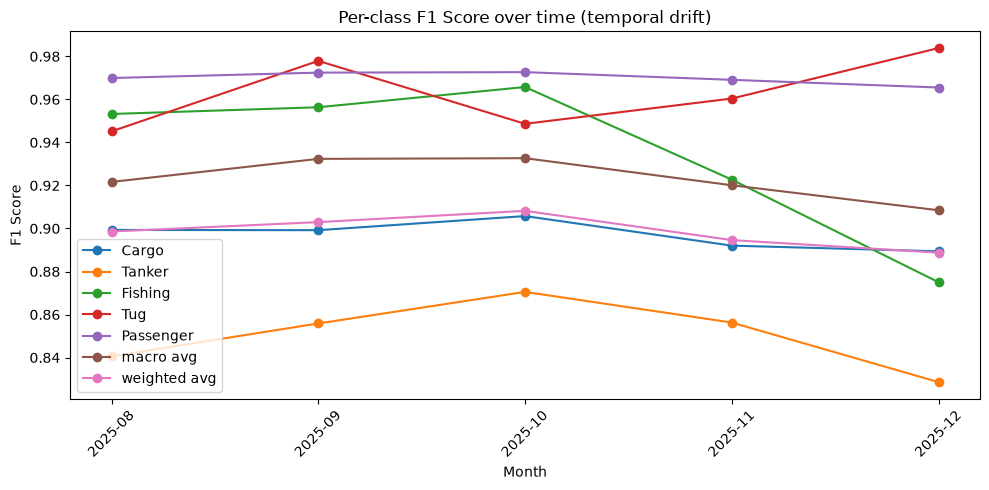

In [135]:
import matplotlib.pyplot as plt
import pandas as pd

classes = ["Cargo", "Tanker", "Fishing", "Tug", "Passenger","macro avg","weighted avg"]
months = list(reports.keys())

fig, ax = plt.subplots(figsize=(10, 5))
for cls in classes:
    f1_scores = []
    for month in months:
        report = reports[month]
        f1 = report.get(cls, {}).get("recall", None)
        f1_scores.append(f1)
    ax.plot(months, f1_scores, marker="o", label=cls)

ax.set_xlabel("Month")
ax.set_ylabel("F1 Score")
ax.set_title("Per-class F1 Score over time (temporal drift)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

C:\Users\mlr\AppData\Local\Temp\ipykernel_23144\252044120.py:16: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


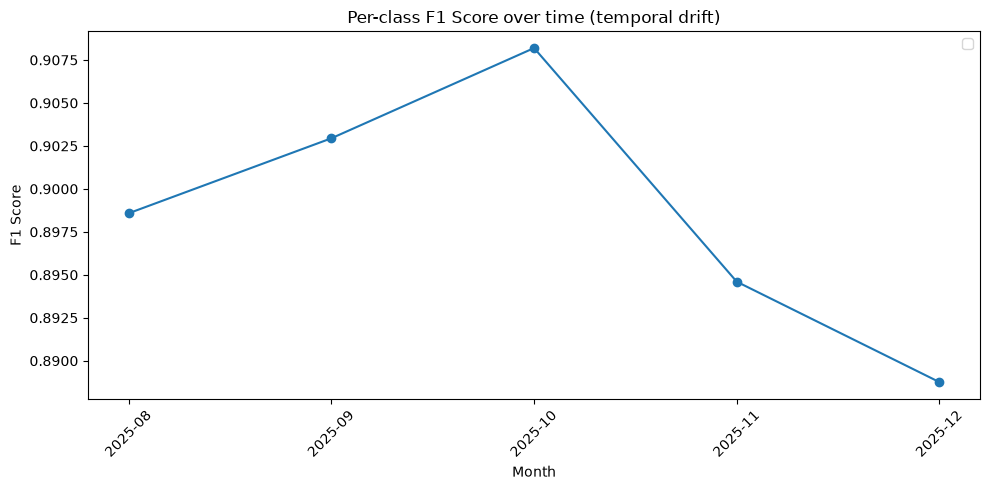

In [ ]:

classes = ["macro avg","weighted avg"]
months = list(reports.keys())

fig, ax = plt.subplots(figsize=(10, 5))

acc = []
for month in months:
    report = reports[month]
    f1 = report["accuracy"]
    acc.append(f1)
ax.plot(months, f1_scores, marker="o")

ax.set_xlabel("Month")
ax.set_ylabel("Accuracy")
ax.set_title("Per-class F1 Score over time (temporal drift)")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [133]:
print(reports[9])

KeyError: 9